In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/traffic.csv", encoding='latin1')
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores MÃ¡s,No Llores MÃ¡s,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,MalÃ©,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [5]:
df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
event,0
date,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121
linkid,0


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.fillna("Unknown", inplace=True)

In [9]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
df['month'] = df['date'].dt.month

In [11]:
total_events = df['event'].count()

print("Total Events:", total_events)

Total Events: 122567


In [12]:
total_users = df['linkid'].nunique()

print("Total Users:", total_users)

Total Users: 3839


In [13]:
bounce_rate = (df['event'].value_counts().min() / total_events) * 100

print("Bounce Rate:", bounce_rate)

Bounce Rate: 13.631727952874753


In [14]:
avg_activity = total_events / total_users

print("Average Activity per User:", avg_activity)

Average Activity per User: 31.92680385517062


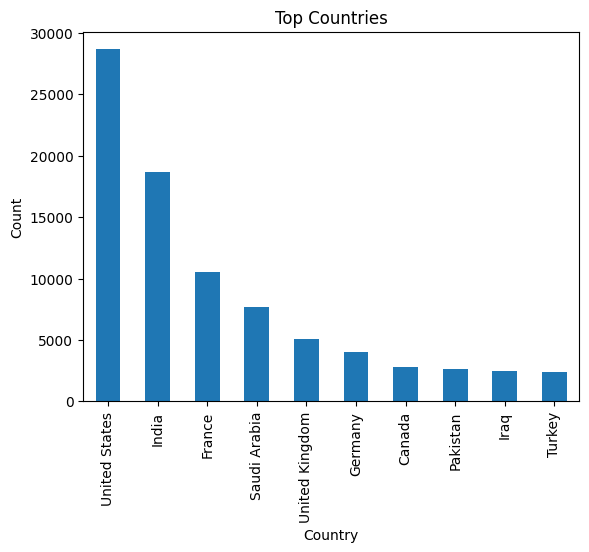

In [15]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')

plt.title('Top Countries')
plt.xlabel('Country')
plt.ylabel('Count')

plt.show()

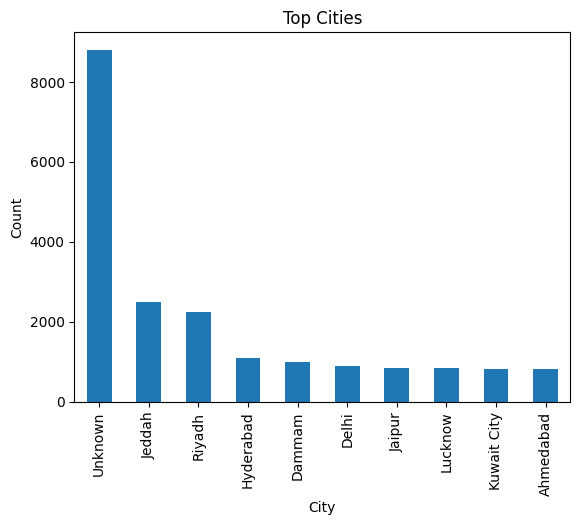

In [16]:
top_cities = df['city'].value_counts().head(10)

top_cities.plot(kind='bar')

plt.title('Top Cities')
plt.xlabel('City')
plt.ylabel('Count')

plt.show()

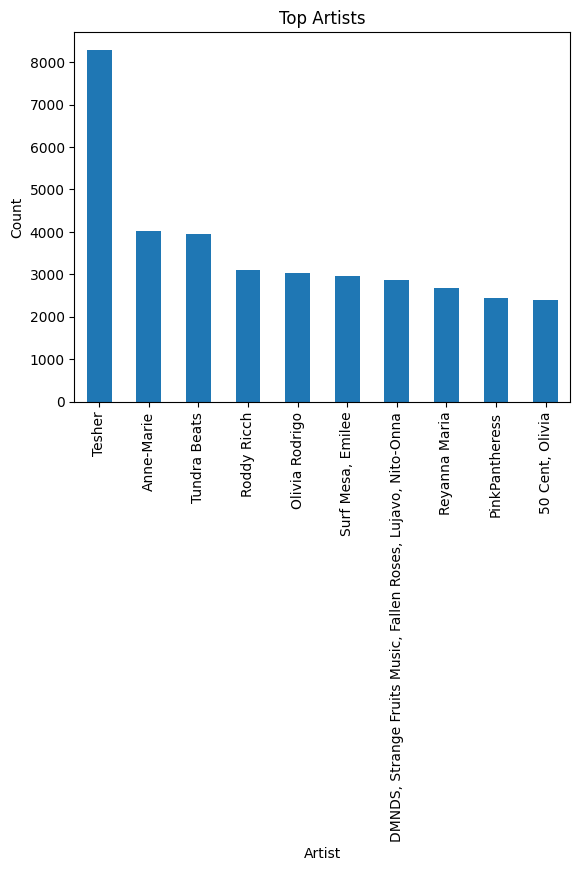

In [17]:
top_artists = df['artist'].value_counts().head(10)

top_artists.plot(kind='bar')

plt.title('Top Artists')
plt.xlabel('Artist')
plt.ylabel('Count')

plt.show()

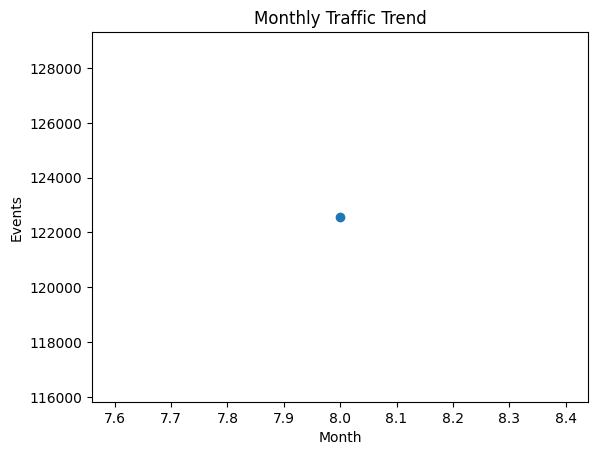

In [18]:
monthly = df.groupby('month')['event'].count()

monthly.plot(kind='line', marker='o')

plt.title('Monthly Traffic Trend')
plt.xlabel('Month')
plt.ylabel('Events')

plt.show()

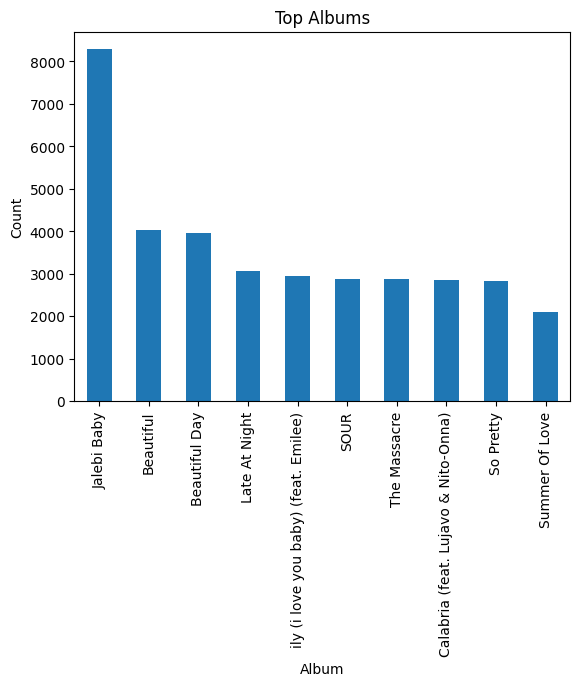

In [19]:
top_albums = df['album'].value_counts().head(10)

top_albums.plot(kind='bar')

plt.title('Top Albums')
plt.xlabel('Album')
plt.ylabel('Count')

plt.show()

OBSERVATIONS

1. Certain countries generated higher website traffic.
2. Some cities showed greater user engagement.
3. Popular artists and albums attracted more user activity.
4. Monthly traffic changed across different months.
5. User activity varied based on event interactions.

RECOMMENDATIONS

1. Focus promotions in high-traffic countries.
2. Improve engagement strategies in low-performing cities.
3. Promote trending artists and albums more effectively.
4. Use seasonal marketing campaigns during high-traffic months.
5. Improve user experience to reduce bounce behavior.